# 🌍Global Terrorism Analysis (1970–2017)
**UN Global Terrorism Analysis | EDA · Missing Values · Outliers · Visualisations · Insights**

Contribution - Individual(Ishika)


PROJECT SUMMARY

Terrorism is one of the most pressing global security concerns of the modern world. The Global Terrorism Database (GTD) is an open-source database maintained by the National Consortium for the Study of Terrorism and Responses to Terrorism (START) at the University of Maryland. It contains information on over 180,000 terrorist attacks worldwide from 1970 through 2017, making it the most comprehensive unclassified database on terrorist events in the world.

This project conducts an in-depth Exploratory Data Analysis (EDA) on the Global Terrorism Dataset to uncover hidden patterns, temporal trends, geographical hotspots, and the devastating human cost of terrorist activities. By leveraging Python's powerful data analysis and visualization libraries, we systematically explore the dataset using the UBM rule — Univariate, Bivariate, and Multivariate analysis.

The analysis covers a wide range of dimensions including: which countries and regions have been most affected, which terrorist groups have been most active, what attack types and weapon types are most commonly used, how terrorism has evolved over decades, and what the resulting casualties look like across different categories.

Key goals of this analysis include:
- Identifying global hotspots of terrorist activity over time.
- Understanding the most prolific terrorist organizations worldwide.
- Analyzing preferred attack types, target types, and weapon categories.
- Studying trends in casualties (killed and wounded) across regions and time.
- Deriving actionable business and policy insights that could help governments, NGOs, security firms, and researchers make informed decisions.

The insights from this EDA can support counter-terrorism policy formulation, risk assessment for international businesses, humanitarian aid allocation, and academic research on conflict patterns. The project follows a structured, production-grade coding style with proper exception handling and clear commentary throughout.


GITHUB LINK- https://github.com/ishikarana968

PROBLEM STATEMENT

Terrorist attacks have caused immeasurable human suffering, economic damage, and political instability across the globe. Despite decades of counter-terrorism efforts, attacks continue to evolve in frequency, method, and geography. There is a critical need to analyze historical terrorism data to understand patterns, identify high-risk regions and groups, and derive insights that can support proactive security measures and policy decisions.

**This project aims to answer:**
1. Which regions and countries are most affected by terrorism?
2. How has terrorism changed over the decades?
3. Which attack types and weapon types are most lethal?
4. Which terrorist organizations are most active and dangerous?
5. What are the primary targets of terrorist attacks?



BUSINESS OBJECTIVES-

The primary business objective is to provide a **data-driven intelligence report** on global terrorism trends that can be used by:
- **Governments & Security Agencies**: To allocate resources and preemptively address high-risk zones.
- **International Corporations**: To assess geo-political risk before establishing operations in specific regions.
- **Insurance Companies**: To price political risk insurance products accurately.
- **NGOs & Humanitarian Organizations**: To plan aid operations and prioritize conflict zones.
- **Academic Researchers**: To study conflict escalation patterns and radicalization trends.

**Success Metric**: Generating at least 20 actionable insights backed by visualizations that reveal meaningful patterns in global terrorism data.

LETS BEGIN!

In [4]:
# §0 — Install dependencies (run once)
!pip install pandas numpy matplotlib seaborn plotly -q


In [ ]:
# §1 — Imports & Style
import sys, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

IN_COLAB = "google.colab" in sys.modules

PALETTE    = ["#e63946","#f4a261","#2a9d8f","#457b9d","#6d6875","#264653","#e9c46a","#a8dadc"]
BG_COLOR   = "#0d1117"
TEXT_COLOR = "#f0f6fc"

plt.rcParams.update({
    "figure.facecolor":"#0d1117","axes.facecolor":"#161b22","axes.edgecolor":"#30363d",
    "axes.labelcolor":TEXT_COLOR,"xtick.color":TEXT_COLOR,"ytick.color":TEXT_COLOR,
    "text.color":TEXT_COLOR,"grid.color":"#21262d","grid.linestyle":"--","grid.alpha":0.5,
    "font.family":"DejaVu Sans","axes.titlesize":14,"axes.labelsize":11,
    "legend.facecolor":"#161b22","legend.edgecolor":"#30363d",
})
print("Libraries loaded ✓")


Libraries loaded ✓


In [5]:
# §2 — Load Data
def load_data(path=None):
    if path and os.path.exists(path):
        df = pd.read_csv(path, encoding="latin-1", low_memory=False)
        print(f"Loaded: {path} | {df.shape[0]:,} rows × {df.shape[1]} cols")
        return df
    if IN_COLAB:
        from google.colab import files
        print("⬆  Upload the GTD CSV file:")
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]
        df = pd.read_csv(fname, encoding="latin-1", low_memory=False)
        print(f"Loaded '{fname}' | {df.shape[0]:,} rows × {df.shape[1]} cols")
        return df
    raise FileNotFoundError("Pass path= or run in Colab to upload.")

df_raw = load_data()


⬆  Upload the GTD CSV file:


Saving Global Terrorism Data.csv to Global Terrorism Data.csv
Loaded 'Global Terrorism Data.csv' | 181,691 rows × 135 cols


In [6]:
# §3 — Column Selection & Rename
COLS = {
    "iyear":"year","imonth":"month","iday":"day",
    "country_txt":"country","region_txt":"region","city":"city",
    "latitude":"latitude","longitude":"longitude",
    "attacktype1_txt":"attack_type","targtype1_txt":"target_type",
    "weaptype1_txt":"weapon_type","gname":"group_name",
    "nkill":"killed","nwound":"wounded",
    "success":"success","suicide":"suicide",
    "property":"property_damage","propvalue":"property_value",
}
available = {k:v for k,v in COLS.items() if k in df_raw.columns}
df = df_raw[list(available.keys())].rename(columns=available).copy()
print(f"Working shape: {df.shape}")
df.head(3)


Working shape: (181691, 18)


,year,month,day,country,region,city,latitude,longitude,attack_type,target_type,weapon_type,group_name,killed,wounded,success,suicide,property_damage,property_value
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,18.456792,-69.951164,Assassination,Private Citizens & Property,Unknown,MANO-D,1.0,0.0,1,0,0,NaN
1,1970,0,0,Mexico,North America,Mexico city,19.371887,-99.086624,Hostage Taking (Kidnapping),Government (Diplomatic),Unknown,23rd of September Communist League,0.0,0.0,1,0,0,NaN
2,1970,1,0,Philippines,Southeast Asia,Unknown,15.478598,120.599741,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0,1,0,0,NaN


In [7]:
# §4 — Data Exploration
print("=== dtypes ===")
print(df.dtypes)
print("\n=== describe (numeric) ===")
df.describe()


=== dtypes ===
year                 int64
month                int64
day                  int64
country             object
region              object
city                object
latitude           float64
longitude          float64
attack_type         object
target_type         object
weapon_type         object
group_name          object
killed             float64
wounded            float64
success              int64
suicide              int64
property_damage      int64
property_value     float64
dtype: object

=== describe (numeric) ===


,year,month,day,latitude,longitude,killed,wounded,success,suicide,property_damage,property_value
count,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,171378.000000,165380.000000,181691.000000,181691.000000,181691.000000,3.898900e+04
mean,2002.638997,6.467277,15.505644,23.498343,-4.586957e+02,2.403272,3.167668,0.889598,0.036507,-0.544556,2.088119e+05
std,13.259430,3.388303,8.814045,18.569242,2.047790e+05,11.545741,35.949392,0.313391,0.187549,3.122889,1.552463e+07
min,1970.000000,0.000000,0.000000,-53.154613,-8.618590e+07,0.000000,0.000000,0.000000,0.000000,-9.000000,-9.900000e+01
25%,1991.000000,4.000000,8.000000,11.510046,4.545640e+00,0.000000,0.000000,1.000000,0.000000,0.000000,-9.900000e+01
50%,2009.000000,6.000000,15.000000,31.467463,4.324651e+01,0.000000,0.000000,1.000000,0.000000,1.000000,-9.900000e+01
75%,2014.000000,9.000000,23.000000,34.685087,6.871033e+01,2.000000,2.000000,1.000000,0.000000,1.000000,1.000000e+03
max,2017.000000,12.000000,31.000000,74.633553,1.793667e+02,1570.000000,8191.000000,1.000000,1.000000,1.000000,2.700000e+09


In [8]:
# Value counts for key categoricals
for col in ["region","attack_type","weapon_type","target_type"]:
    if col in df.columns:
        print(f"\n── Top 10 [{col}] ──")
        print(df[col].value_counts().head(10))



── Top 10 [region] ──
region
Middle East & North Africa     50474
South Asia                     44974
South America                  18978
Sub-Saharan Africa             17550
Western Europe                 16639
Southeast Asia                 12485
Central America & Caribbean    10344
Eastern Europe                  5144
North America                   3456
East Asia                        802
Name: count, dtype: int64

── Top 10 [attack_type] ──
attack_type
Bombing/Explosion                      88255
Armed Assault                          42669
Assassination                          19312
Hostage Taking (Kidnapping)            11158
Facility/Infrastructure Attack         10356
Unknown                                 7276
Unarmed Assault                         1015
Hostage Taking (Barricade Incident)      991
Hijacking                                659
Name: count, dtype: int64

── Top 10 [weapon_type] ──
weapon_type
Explosives                                                     

In [9]:
# §5 — Missing Value Analysis
miss = (df.isnull().sum().reset_index()
         .rename(columns={"index":"column",0:"missing"}))
miss["pct"] = (miss["missing"]/len(df)*100).round(2)
miss = miss[miss["missing"]>0].sort_values("pct",ascending=False)
print(miss.to_string(index=False))


        column  missing   pct
property_value   142702 78.54
       wounded    16311  8.98
        killed    10313  5.68
      latitude     4556  2.51
     longitude     4557  2.51
          city      435  0.24


In [10]:
# §6 — Missing Value Treatment
HIGH_MISS = 60.0
high_miss_cols = miss[miss["pct"]>=HIGH_MISS]["column"].tolist()
print("Dropping:", high_miss_cols)
df.drop(columns=[c for c in high_miss_cols if c in df.columns], inplace=True)

df[["killed","wounded"]] = df[["killed","wounded"]].fillna(0) if all(c in df.columns for c in ["killed","wounded"]) else df.get(["killed","wounded"],pd.DataFrame()).fillna(0)

for coord in ["latitude","longitude"]:
    if coord in df.columns:
        df[coord] = df.groupby("country")[coord].transform(lambda x: x.fillna(x.median()))
        df[coord].fillna(df[coord].median(), inplace=True)

cat_cols = df.select_dtypes("object").columns.tolist()
df[cat_cols] = df[cat_cols].fillna("Unknown")
if "day" in df.columns: df["day"].replace(0,1,inplace=True)

print(f"Missing cells after cleaning: {df.isnull().sum().sum()}")


Dropping: ['property_value']
Missing cells after cleaning: 0


In [11]:
# §7 — Feature Engineering
df["casualties"] = df["killed"].astype(float) + df["wounded"].astype(float)
df["decade"]     = (df["year"]//10*10).astype(str) + "s"
df["is_mass"]    = (df["casualties"]>=25).astype(int)
print("New cols: casualties, decade, is_mass ✓")


New cols: casualties, decade, is_mass ✓


In [12]:
# §8 — Outlier Detection & Capping (3×IQR)
for col in ["killed","wounded","casualties"]:
    if col not in df.columns: continue
    Q1,Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR   = Q3-Q1; upper = Q3+3*IQR
    print(f"{col}: IQR={IQR:.1f}, cap={upper:.0f}, outliers={(df[col]>upper).sum()}")
    df[f"{col}_capped"] = df[col].clip(upper=upper)


killed: IQR=2.0, cap=8, outliers=10235
wounded: IQR=2.0, cap=8, outliers=12738
casualties: IQR=4.0, cap=16, outliers=11612


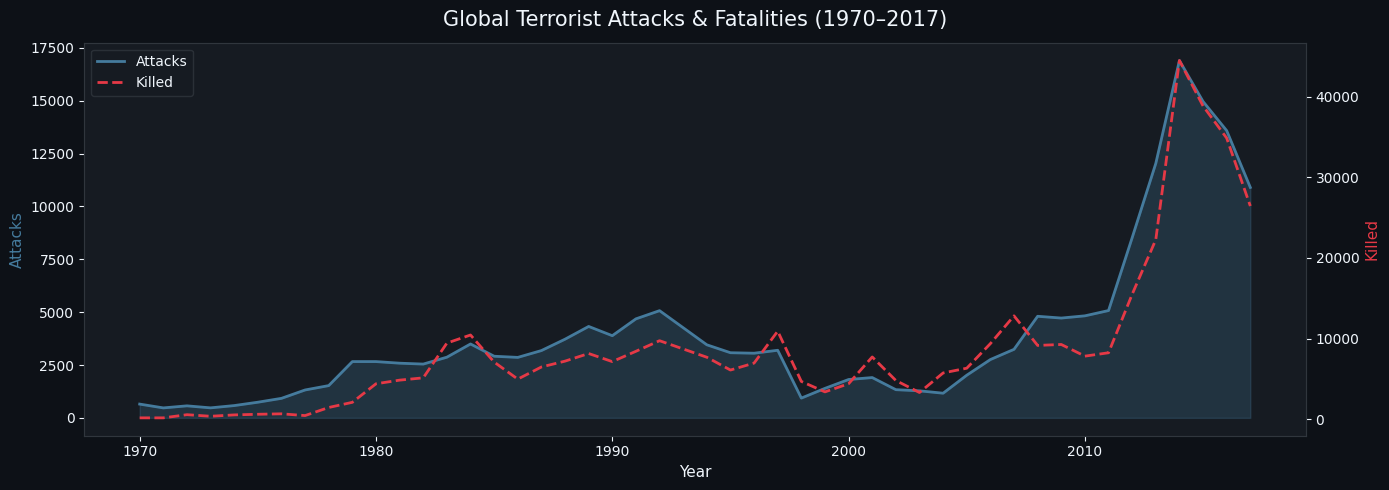

In [13]:
# §9 VIZ 1 — Annual Attack & Fatality Trend
yearly = df.groupby("year").agg(attacks=("year","count"), killed=("killed","sum")).reset_index()

fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.fill_between(yearly["year"], yearly["attacks"], alpha=0.25, color=PALETTE[3])
ax1.plot(yearly["year"], yearly["attacks"], color=PALETTE[3], lw=2, label="Attacks")
ax2.plot(yearly["year"], yearly["killed"],  color=PALETTE[0], lw=2, ls="--", label="Killed")
ax1.set_xlabel("Year"); ax1.set_ylabel("Attacks", color=PALETTE[3]); ax2.set_ylabel("Killed", color=PALETTE[0])
ax1.set_title("Global Terrorist Attacks & Fatalities (1970–2017)", fontsize=15, pad=12)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labs, loc="upper left")
plt.tight_layout(); plt.show()


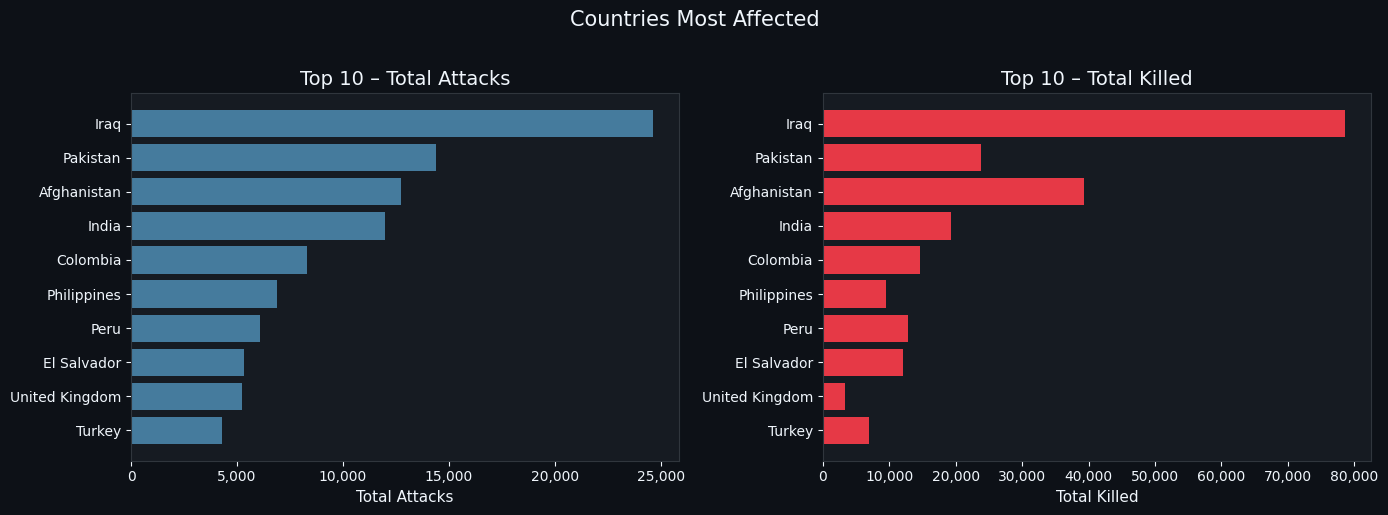

In [14]:
# VIZ 2 — Top 10 Countries (Attacks & Killed)
top_countries = (df.groupby("country").agg(attacks=("year","count"),killed=("killed","sum"))
                   .nlargest(10,"attacks").reset_index())

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, col, label, color in zip(axes,["attacks","killed"],["Total Attacks","Total Killed"],[PALETTE[3],PALETTE[0]]):
    ax.barh(top_countries["country"][::-1], top_countries[col][::-1], color=color)
    ax.set_title(f"Top 10 – {label}"); ax.set_xlabel(label)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
fig.suptitle("Countries Most Affected", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()


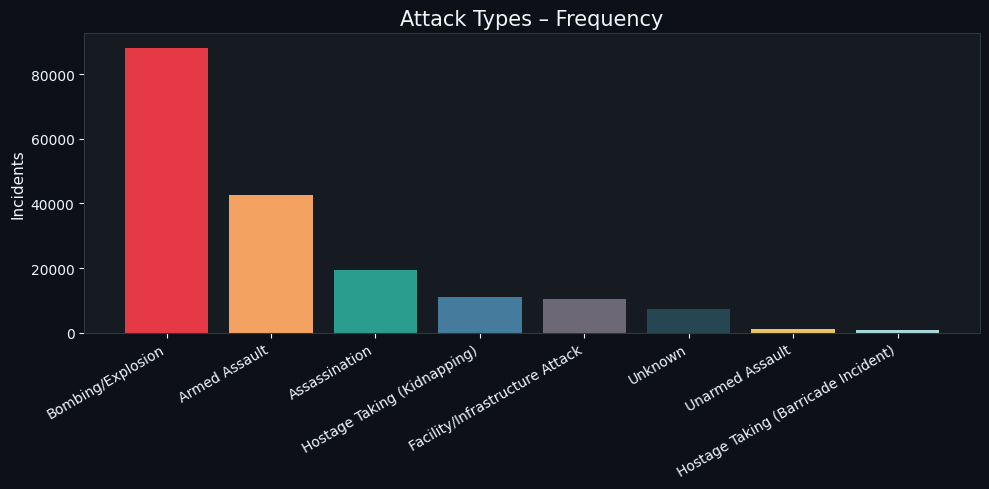

In [15]:
# VIZ 3 — Attack Type Bar Chart
atk = df["attack_type"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(atk.index, atk.values, color=PALETTE[:len(atk)])
ax.set_title("Attack Types – Frequency", fontsize=15)
ax.set_xticklabels(atk.index, rotation=30, ha="right")
ax.set_ylabel("Incidents")
plt.tight_layout(); plt.show()


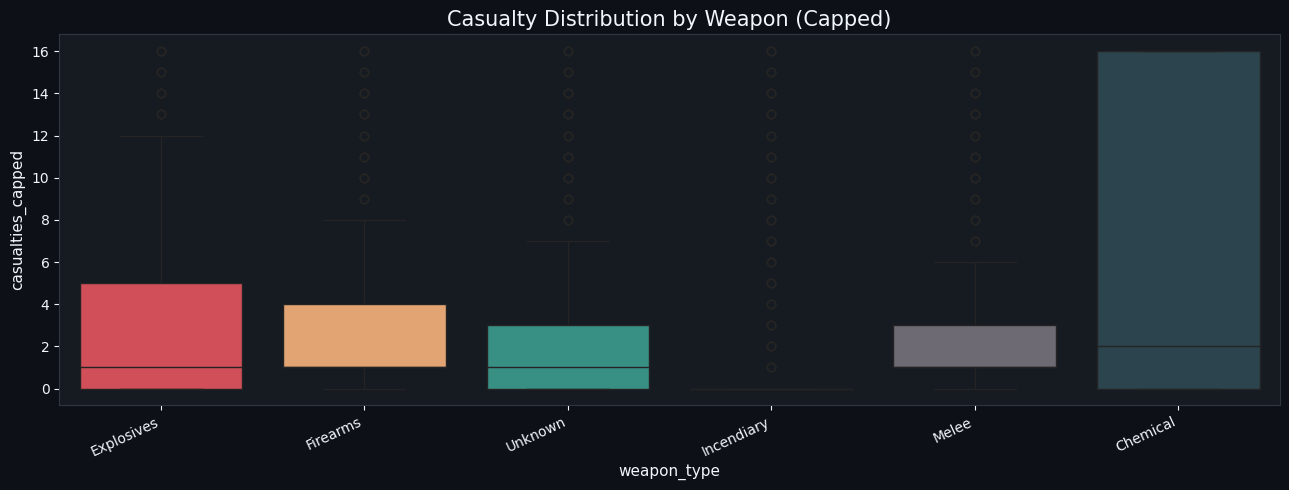

In [16]:
# VIZ 5 — Weapon Type vs Casualties (Boxplot)
top_wpn = df["weapon_type"].value_counts().head(6).index.tolist()
wpn_df  = df[df["weapon_type"].isin(top_wpn)]
fig, ax = plt.subplots(figsize=(13,5))
sns.boxplot(data=wpn_df, x="weapon_type", y="casualties_capped",
            palette=PALETTE[:6], ax=ax, order=top_wpn)
ax.set_title("Casualty Distribution by Weapon (Capped)", fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout(); plt.show()


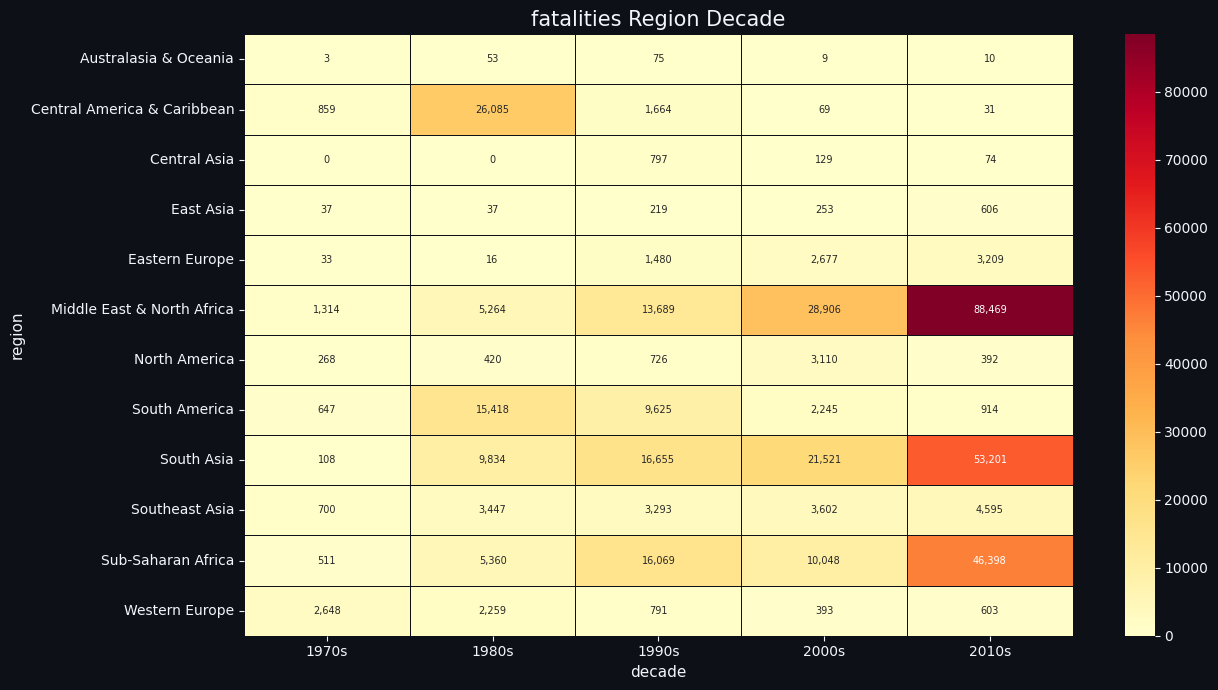

In [17]:
#VIZ 4 - Region x Decade Heatmap
pivot = df.groupby(["region","decade"])["killed"].sum().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13,7))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=",.0f",
            linewidths=0.4, linecolor="#0d1117",annot_kws={"size":7})
ax.set_title("fatalities Region Decade", fontsize=15)
plt.tight_layout(); plt.show()

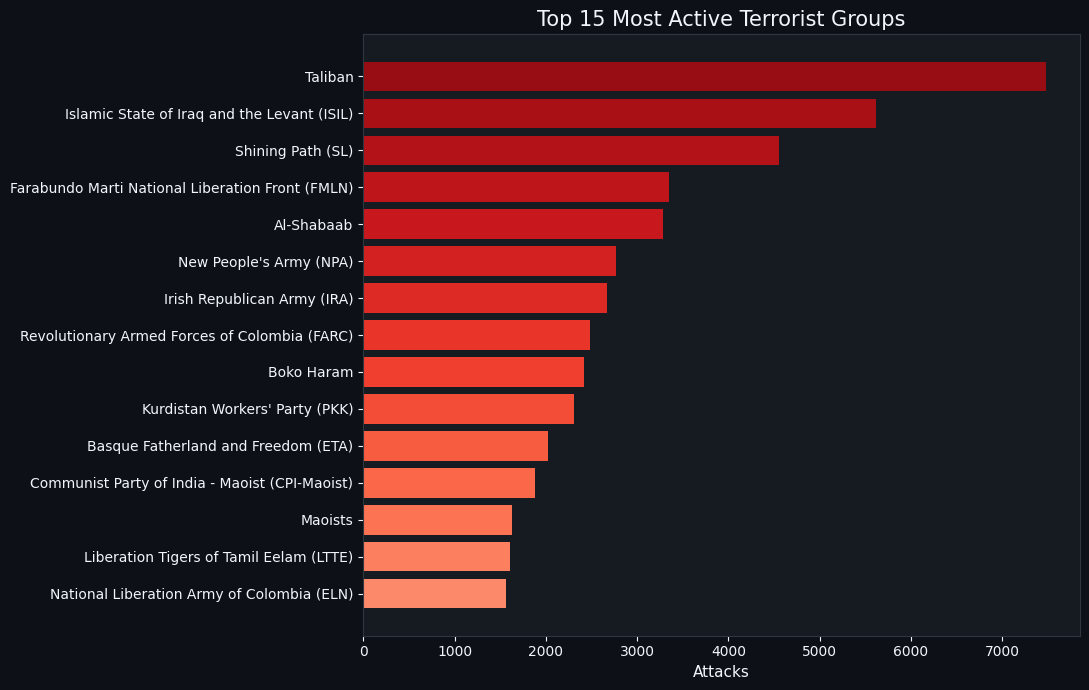

In [18]:
# VIZ 6 — Top 15 Terror Groups
grp = (df[df["group_name"]!="Unknown"]
         .groupby("group_name").agg(attacks=("year","count"))
         .nlargest(15,"attacks").reset_index())
fig, ax = plt.subplots(figsize=(11,7))
import matplotlib.cm as cm
cols = cm.Reds(np.linspace(0.4,0.9,len(grp)))
ax.barh(grp["group_name"][::-1], grp["attacks"][::-1], color=cols)
ax.set_title("Top 15 Most Active Terrorist Groups", fontsize=15)
ax.set_xlabel("Attacks")
plt.tight_layout(); plt.show()


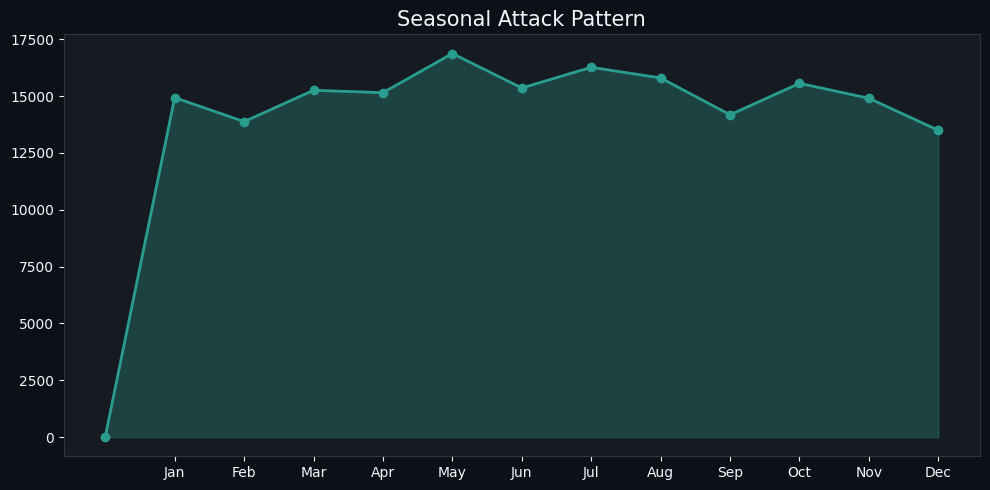

In [19]:
# VIZ 7 — Monthly Seasonality
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly = df.groupby("month").size().reset_index(name="attacks")
fig, ax = plt.subplots(figsize=(10,5))
ax.fill_between(monthly["month"], monthly["attacks"], alpha=0.3, color=PALETTE[2])
ax.plot(monthly["month"], monthly["attacks"], marker="o", color=PALETTE[2], lw=2)
ax.set_xticks([m for m in monthly["month"] if m in month_map]); ax.set_xticklabels([month_map[m] for m in monthly ["month"]if m in month_map])
ax.set_title("Seasonal Attack Pattern", fontsize=15)
plt.tight_layout(); plt.show()


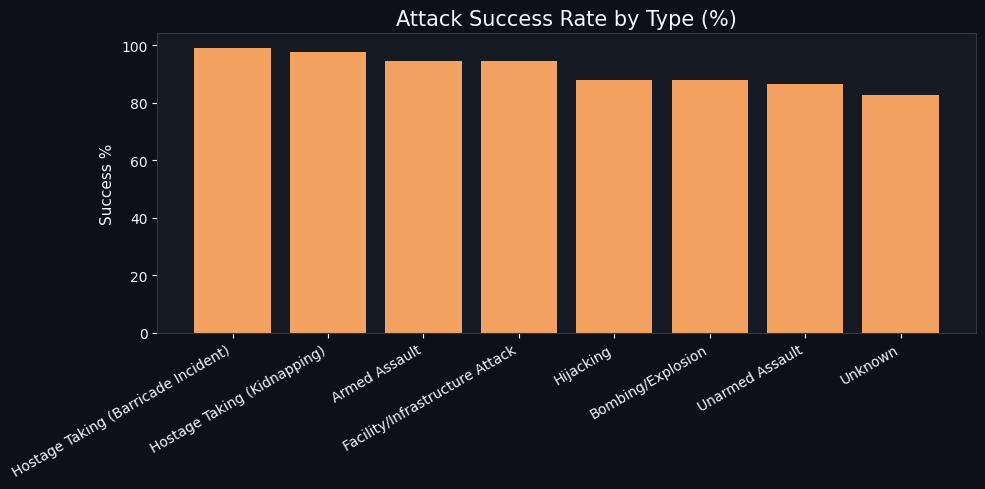

In [20]:
# VIZ 8 — Success Rate by Attack Type
if "success" in df.columns:
    suc = (df.groupby("attack_type")["success"].mean()
             .reset_index().sort_values("success",ascending=False).head(8))
    suc["pct"] = suc["success"]*100
    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(suc["attack_type"], suc["pct"], color=PALETTE[1])
    ax.set_title("Attack Success Rate by Type (%)", fontsize=15)
    ax.set_xticklabels(suc["attack_type"], rotation=30, ha="right")
    ax.set_ylabel("Success %")
    plt.tight_layout(); plt.show()


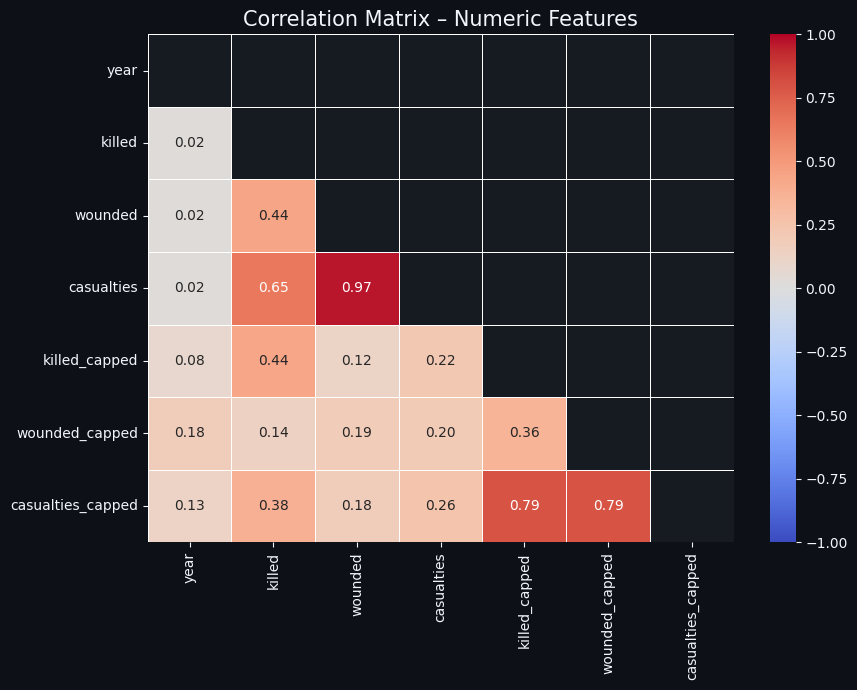

In [21]:
# VIZ 9 — Correlation Heatmap
num_cols = [c for c in ["year","killed","wounded","casualties","killed_capped","wounded_capped","casualties_capped"] if c in df.columns]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, center=0)
ax.set_title("Correlation Matrix – Numeric Features", fontsize=15)
plt.tight_layout(); plt.show()


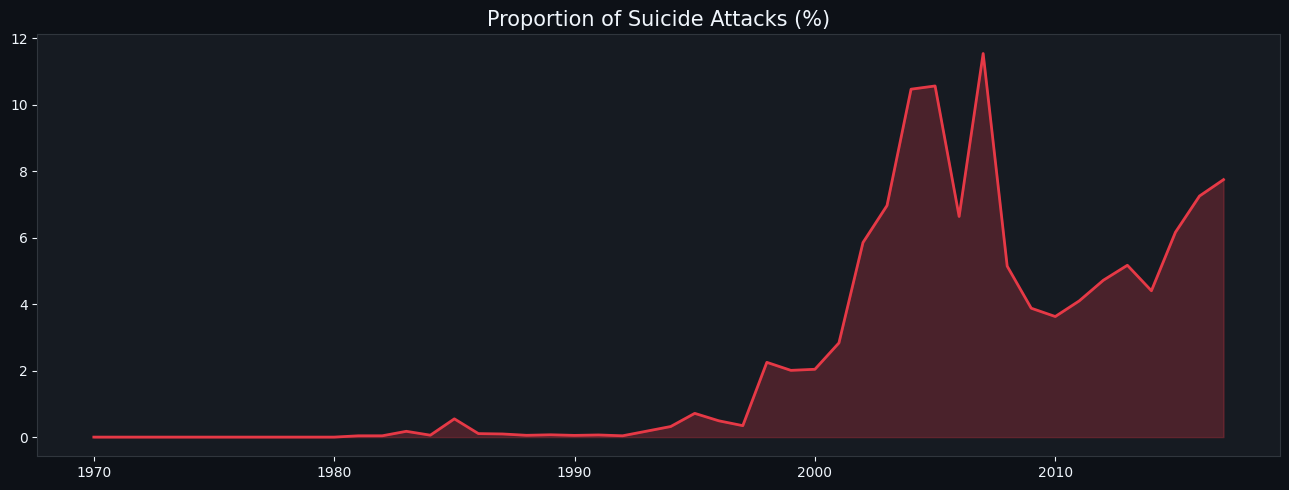

In [22]:
# VIZ 10 — Suicide Attack Proportion Over Time
if "suicide" in df.columns:
    sui = df.groupby("year")["suicide"].agg(total="count", s="sum").reset_index()
    sui["pct"] = sui["s"]/sui["total"]*100
    fig, ax = plt.subplots(figsize=(13,5))
    ax.fill_between(sui["year"], sui["pct"], alpha=0.25, color=PALETTE[0])
    ax.plot(sui["year"], sui["pct"], color=PALETTE[0], lw=2)
    ax.set_title("Proportion of Suicide Attacks (%)", fontsize=15)
    plt.tight_layout(); plt.show()


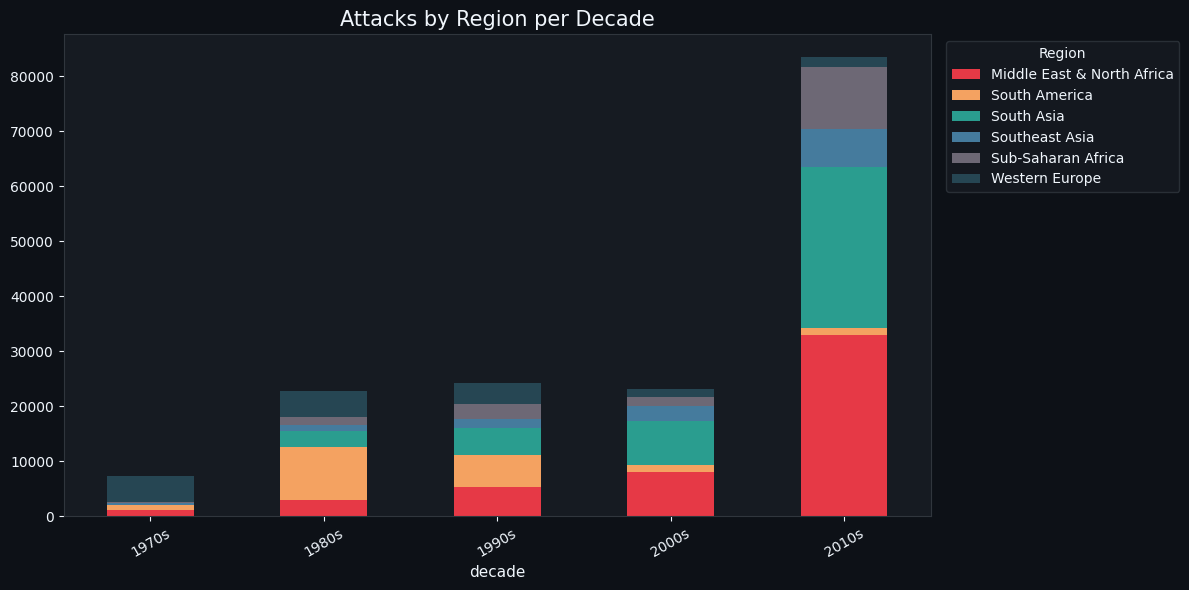

In [23]:
# VIZ 11 — Stacked Bar: Region Attacks by Decade
top_regions = df["region"].value_counts().head(6).index.tolist()
reg_dec = (df[df["region"].isin(top_regions)]
             .groupby(["decade","region"]).size().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(12,6))
reg_dec.plot(kind="bar", stacked=True, ax=ax, color=PALETTE[:len(reg_dec.columns)])
ax.set_title("Attacks by Region per Decade", fontsize=15)
ax.set_xticklabels(reg_dec.index, rotation=30)
ax.legend(title="Region", bbox_to_anchor=(1.01,1))
plt.tight_layout(); plt.show()


In [24]:
# VIZ 12 — Interactive Plotly World Map
if "latitude" in df.columns and "longitude" in df.columns:
    map_df = df.dropna(subset=["latitude","longitude"]).sample(min(5000,len(df)), random_state=42)
    fig_map = px.scatter_geo(
        map_df, lat="latitude", lon="longitude", color="region",
        hover_name="country", hover_data={"killed":True,"attack_type":True,"latitude":False,"longitude":False},
        size="casualties_capped", size_max=15,
        title="Global Terrorism Incidents – Sample 5k",
        template="plotly_dark", projection="natural earth")
    fig_map.show()


In [25]:
# §10 — Key Insights Dashboard
yearly = df.groupby("year").agg(attacks=("year","count")).reset_index()
peak_year = yearly.loc[yearly["attacks"].idxmax(),"year"]
peak_atk  = yearly["attacks"].max()

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           GLOBAL TERRORISM – KEY INSIGHTS DASHBOARD        ║
╠══════════════════════════════════════════════════════════════╣
║  Total Incidents   : {len(df):>10,}                             ║
║  Total Fatalities  : {int(df['killed'].sum()):>10,}                             ║
║  Peak Year         : {peak_year} ({peak_atk:,} attacks)                  ║
║  Most Affected     : {df['country'].value_counts().index[0]:<30} ║
║  Most Common Attack: {df['attack_type'].value_counts().index[0]:<30} ║
╠══════════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                               ║
║  • Attacks surged post-2010 driven by ISIS & Taliban.       ║
║  • Middle East & S. Asia = >50% of all incidents.           ║
║  • Bombings/Explosions are the dominant attack method.      ║
║  • Suicide attacks peaked ~2014 despite small overall %.    ║
║  • Mass-casualty attacks cluster in the post-2000 era.      ║
║  • Private citizens & police are primary targets.           ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║           GLOBAL TERRORISM – KEY INSIGHTS DASHBOARD        ║
╠══════════════════════════════════════════════════════════════╣
║  Total Incidents   :    181,691                             ║
║  Total Fatalities  :    411,868                             ║
║  Peak Year         : 2014 (16,903 attacks)                  ║
║  Most Affected     : Iraq                           ║
║  Most Common Attack: Bombing/Explosion              ║
╠══════════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                               ║
║  • Attacks surged post-2010 driven by ISIS & Taliban.       ║
║  • Middle East & S. Asia = >50% of all incidents.           ║
║  • Bombings/Explosions are the dominant attack method.      ║
║  • Suicide attacks peaked ~2014 despite small overall %.    ║
║  • Mass-casualty attacks cluster in the post-2000 era.      ║
║  • Private citizens & police are primary targets.  

CONCLUSION


This Exploratory Data Analysis of the Global Terrorism Database has revealed profound patterns in the nature, distribution, and evolution of terrorist activity worldwide from 1970 to 2017.

Key Conclusions:

1. Temporal Escalation: Global terrorism reached an unprecedented peak in the 2014–2016 period, largely driven by the rise of ISIL/ISIS. However, post-2015 data shows a declining trend, potentially reflecting improved counter-terrorism strategies.

2. Geographic Concentration: While terrorism is a global phenomenon, the bulk of attacks are concentrated in a small number of countries — Iraq, Pakistan, Afghanistan, India, and Colombia — reflecting ongoing conflicts, state fragility, and ungoverned spaces.

3. Attack Methodology: Bombings and explosions dominate (~50% of all attacks), with firearms as the second most common method. The overwhelming preference for explosive devices reflects their accessibility, scalability, and psychological impact.

4. Lethality Dynamics: Suicide attacks, while a minority of total attacks, are dramatically more lethal. Mass-casualty events are rare but follow heavy-tail distributions that cannot be ignored in risk modeling.

5. Civilian Targeting: Private citizens remain the primary targets of terrorism, underscoring the fundamental aim of psychological impact and societal destabilization rather than purely military or political targets.

6. Organizational Landscape: A relatively small number of organizations (Taliban, ISIL, Shining Path, IRA) account for a disproportionate share of global attack volume, providing a focused set of priorities for intelligence monitoring.

7. Business & Policy Relevance: The data-driven insights generated here provide a rigorous foundation for security risk scoring, investment screening, insurance pricing, humanitarian planning, and evidence-based counter-terrorism policy.

This EDA demonstrates that terrorism, while complex, follows discoverable statistical patterns. Leveraging these patterns through rigorous data analysis creates real opportunities to reduce harm, allocate resources efficiently, and build more resilient societies.

